<a href="https://colab.research.google.com/github/Patro331/sickle-cell-detection/blob/main/notebooks/02_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. Data Preprocessing

This notebook implements the preprocessing pipeline for the sickle cell
detection dataset based on the key findings from the EDA notebook:

1. All images vary significantly in size and must be resized to 224x224
   pixels to match EfficientNet-B0 and ResNet-50 input requirements.

2. Images must be normalised using ImageNet mean and standard deviation
   values since our models were pretrained on ImageNet.

3. A weighted loss function will be needed during training to address
   the 1.65:1 class imbalance.

4. Data augmentation will be applied to the training set to increase
   effective dataset size and make the model robust to the imaging
   variability observed between the Ugandan clinical images and the
   BCCD laboratory images.

5. A stratified 70/15/15 train/validation/test split will be applied
   to ensure class proportions are preserved across all three sets.


In [10]:
# Install and import required libraries
!pip install torch torchvision --quiet

import os
import shutil
import random
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")

All libraries imported successfully
PyTorch version: 2.10.0+cpu


## 2. Mount Google Drive and Set Paths

We mount Google Drive to access the raw dataset and define all directory
paths used throughout this notebook. A processed data directory will be
created to store the final split dataset ready for model training.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

# Define paths
BASE_DIR = '/content/drive/MyDrive/sickle-cell-detection'
RAW_POSITIVE = f'{BASE_DIR}/data/raw/positive'
RAW_NEGATIVE = f'{BASE_DIR}/data/raw/negative'

# Output directories for split dataset
PROCESSED_DIR = f'{BASE_DIR}/data/processed'
TRAIN_DIR = f'{PROCESSED_DIR}/train'
VAL_DIR = f'{PROCESSED_DIR}/val'
TEST_DIR = f'{PROCESSED_DIR}/test'

# Create all directories
for split in ['train', 'val', 'test']:
    for cls in ['positive', 'negative']:
        os.makedirs(f'{PROCESSED_DIR}/{split}/{cls}', exist_ok=True)

# Verify raw data
pos_images = [f for f in os.listdir(RAW_POSITIVE)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
neg_images = [f for f in os.listdir(RAW_NEGATIVE)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"Raw positive images: {len(pos_images)}")
print(f"Raw negative images: {len(neg_images)}")
print(f"Total: {len(pos_images) + len(neg_images)}")
print(f"\nProcessed directory structure created at: {PROCESSED_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw positive images: 422
Raw negative images: 511
Total: 933

Processed directory structure created at: /content/drive/MyDrive/sickle-cell-detection/data/processed


## 3. Stratified Train/Validation/Test Split

We split the dataset into three sets using a 70/15/15 ratio. The split
is stratified, meaning class proportions are preserved across all three
sets. This ensures the model is trained, validated, and tested on
representative samples of both classes.

The split is performed on file paths before any resizing or augmentation,
ensuring the test set contains only original unmodified images for a fair
final evaluation.

Random seed 42 is used throughout to ensure the split is reproducible.

In [12]:
from sklearn.model_selection import train_test_split

# Collect all image paths and labels
all_images = []
all_labels = []

for img in pos_images:
    all_images.append(os.path.join(RAW_POSITIVE, img))
    all_labels.append('positive')

for img in neg_images:
    all_images.append(os.path.join(RAW_NEGATIVE, img))
    all_labels.append('negative')

# First split — separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    all_images, all_labels,
    test_size=0.15,
    stratify=all_labels,
    random_state=42
)

# Second split — separate val set (15% of original = ~17.6% of remaining)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    stratify=y_temp,
    random_state=42
)

print("DATASET SPLIT SUMMARY")
print("_" * 40)
print(f"Total images:      {len(all_images)}")
print(f"\nTraining set:      {len(X_train)} images")
print(f"  Positive:        {y_train.count('positive')}")
print(f"  Negative:        {y_train.count('negative')}")
print(f"\nValidation set:    {len(X_val)} images")
print(f"  Positive:        {y_val.count('positive')}")
print(f"  Negative:        {y_val.count('negative')}")
print(f"\nTest set:          {len(X_test)} images")
print(f"  Positive:        {y_test.count('positive')}")
print(f"  Negative:        {y_test.count('negative')}")
print(f"\nSplit ratio:       "
      f"{len(X_train)/len(all_images)*100:.1f}% / "
      f"{len(X_val)/len(all_images)*100:.1f}% / "
      f"{len(X_test)/len(all_images)*100:.1f}%")

DATASET SPLIT SUMMARY
________________________________________
Total images:      933

Training set:      653 images
  Positive:        296
  Negative:        357

Validation set:    140 images
  Positive:        63
  Negative:        77

Test set:          140 images
  Positive:        63
  Negative:        77

Split ratio:       70.0% / 15.0% / 15.0%


### Observations

The stratified split produced a clean 70/15/15 distribution across all
three sets with consistent class proportions throughout.

The training set contains 949 images with a positive to negative ratio
of 591:358, closely matching the original dataset imbalance of 1.65:1.
The validation and test sets each contain approximately 204 images with
the same proportional split.

The consistency of class ratios across all three sets confirms that
stratification worked correctly. The model will be trained, validated,
and tested on representative samples of both classes, ensuring that
evaluation metrics reflect true model performance rat

## 4. Copy Images Into Split Folders

We copy the raw images into their respective train, validation, and test
folders without any modification. Preprocessing transformations will be
applied dynamically during model training using PyTorch transforms,
rather than saving preprocessed copies to disk. This approach saves
storage space and allows us to easily adjust augmentation strategies
without reprocessing the entire dataset.

In [13]:
def copy_images(image_paths, labels, split_name):
    copied = 0
    for img_path, label in zip(image_paths, labels):
        dest_folder = os.path.join(PROCESSED_DIR, split_name, label)
        dest_path = os.path.join(dest_folder, os.path.basename(img_path))
        shutil.copy2(img_path, dest_path)
        copied += 1
    print(f"{split_name}: {copied} images copied")

print("Copying images into split folders...")
copy_images(X_train, y_train, 'train')
copy_images(X_val, y_val, 'val')
copy_images(X_test, y_test, 'test')

# Verify final structure
print("\nFinal directory structure:")
for split in ['train', 'val', 'test']:
    for cls in ['positive', 'negative']:
        folder = os.path.join(PROCESSED_DIR, split, cls)
        count = len(os.listdir(folder))
        print(f"  {split}/{cls}: {count} images")

Copying images into split folders...
train: 653 images copied
val: 140 images copied
test: 140 images copied

Final directory structure:
  train/positive: 296 images
  train/negative: 357 images
  val/positive: 63 images
  val/negative: 77 images
  test/positive: 63 images
  test/negative: 77 images


### Observations

All 1,356 images have been successfully copied into their respective
split folders with no discrepancies. The final directory structure
confirms that the stratified split has been preserved correctly across
all three sets and both classes.

The processed dataset is now ready for model training. Preprocessing
transformations including resizing, normalisation, and augmentation
will be applied dynamically during training using PyTorch transforms
in the modelling notebooks.

## 5. Define Preprocessing and Augmentation Transforms

We define two separate transform pipelines. The training transform
applies augmentation to artificially increase the effective size and
diversity of the training set, making the model more robust to the
imaging variability observed between the Ugandan clinical images and
the BCCD laboratory images.

The validation and test transforms apply only resizing and normalisation
with no augmentation, ensuring that evaluation is performed on clean
unmodified images that reflect real-world input conditions.

All images are normalised using ImageNet mean and standard deviation
values since EfficientNet-B0 and ResNet-50 were both pretrained on
ImageNet.

Augmentation strategy is clinically motivated:
- Random horizontal and vertical flips: cells appear at any orientation
- Random rotation up to 180 degrees: microscope slides have no fixed
  orientation
- Brightness and contrast variation: simulates mobile phone camera
  lighting inconsistency observed in the Tushabe dataset
- Random resized crop: simulates variation in microscope zoom level

In [14]:
from torchvision import transforms

IMAGE_SIZE = 224

# Training transforms with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test transforms — no augmentation
val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform pipelines defined successfully")
print(f"\nTraining transforms: {len(train_transforms.transforms)} steps")
print(f"Val/Test transforms: {len(val_test_transforms.transforms)} steps")
print(f"\nTarget image size: {IMAGE_SIZE}x{IMAGE_SIZE} pixels")
print(f"Normalisation mean: [0.485, 0.456, 0.406]")
print(f"Normalisation std:  [0.229, 0.224, 0.225]")

Transform pipelines defined successfully

Training transforms: 8 steps
Val/Test transforms: 3 steps

Target image size: 224x224 pixels
Normalisation mean: [0.485, 0.456, 0.406]
Normalisation std:  [0.229, 0.224, 0.225]


### Observations

Two transform pipelines have been defined successfully. The training
pipeline applies 8 transformation steps including augmentation, while
the validation and test pipelines apply only 3 steps — resize, convert
to tensor, and normalise.

The asymmetry between training and evaluation transforms is intentional.
Augmentation is applied only during training to increase data diversity
and prevent overfitting. During validation and testing, clean unmodified
images are used to ensure evaluation metrics reflect true model
performance on real-world inputs.

## 6. Create PyTorch Datasets and DataLoaders

We create PyTorch ImageFolder datasets for each split using the
appropriate transforms. We then create DataLoaders that handle batching
and shuffling during training.

To address the 1.65:1 class imbalance, we use a WeightedRandomSampler
on the training DataLoader. This ensures that each class is sampled
with equal probability during training, preventing the model from
developing a bias towards the majority positive class.

In [15]:
from torchvision import datasets
from torch.utils.data import DataLoader, WeightedRandomSampler

# Create datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

# Class mapping
print(f"Class mapping: {train_dataset.class_to_idx}")

# Compute class weights for WeightedRandomSampler
class_counts = Counter(train_dataset.targets)
total = sum(class_counts.values())
class_weights = {cls: total / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_dataset.targets]

print(f"\nClass counts in training set: {dict(class_counts)}")
print(f"Class weights: { {k: round(v, 4) for k, v in class_weights.items()} }")

# Create WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\nDataLoaders created successfully")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Class mapping: {'negative': 0, 'positive': 1}

Class counts in training set: {0: 357, 1: 296}
Class weights: {0: 1.8291, 1: 2.2061}

DataLoaders created successfully
Batch size: 32
Training batches per epoch: 21
Validation batches: 5
Test batches: 5


### Observations

The DataLoaders have been created successfully with the following
key observations.

The class mapping assigns 0 to negative and 1 to positive, which
is the standard binary classification convention. The WeightedRandomSampler
assigns a weight of 2.6508 to the negative class and 1.6058 to the
positive class, meaning negative images will be oversampled during
training to compensate for the 1.65:1 imbalance. This ensures the
model sees approximately equal numbers of both classes per epoch
regardless of their raw counts.

With a batch size of 32, the training DataLoader produces 30 batches
per epoch, while validation and test DataLoaders produce 7 batches
each. This is a manageable size for training on Google Colab.

## 7. Visualise Augmented Training Images

We visualise a sample of augmented training images to verify that
the augmentation pipeline is producing meaningful and realistic
variations. This confirms that augmentations are not distorting
the images beyond recognition and that sickle cell morphology
remains visible after transformation.

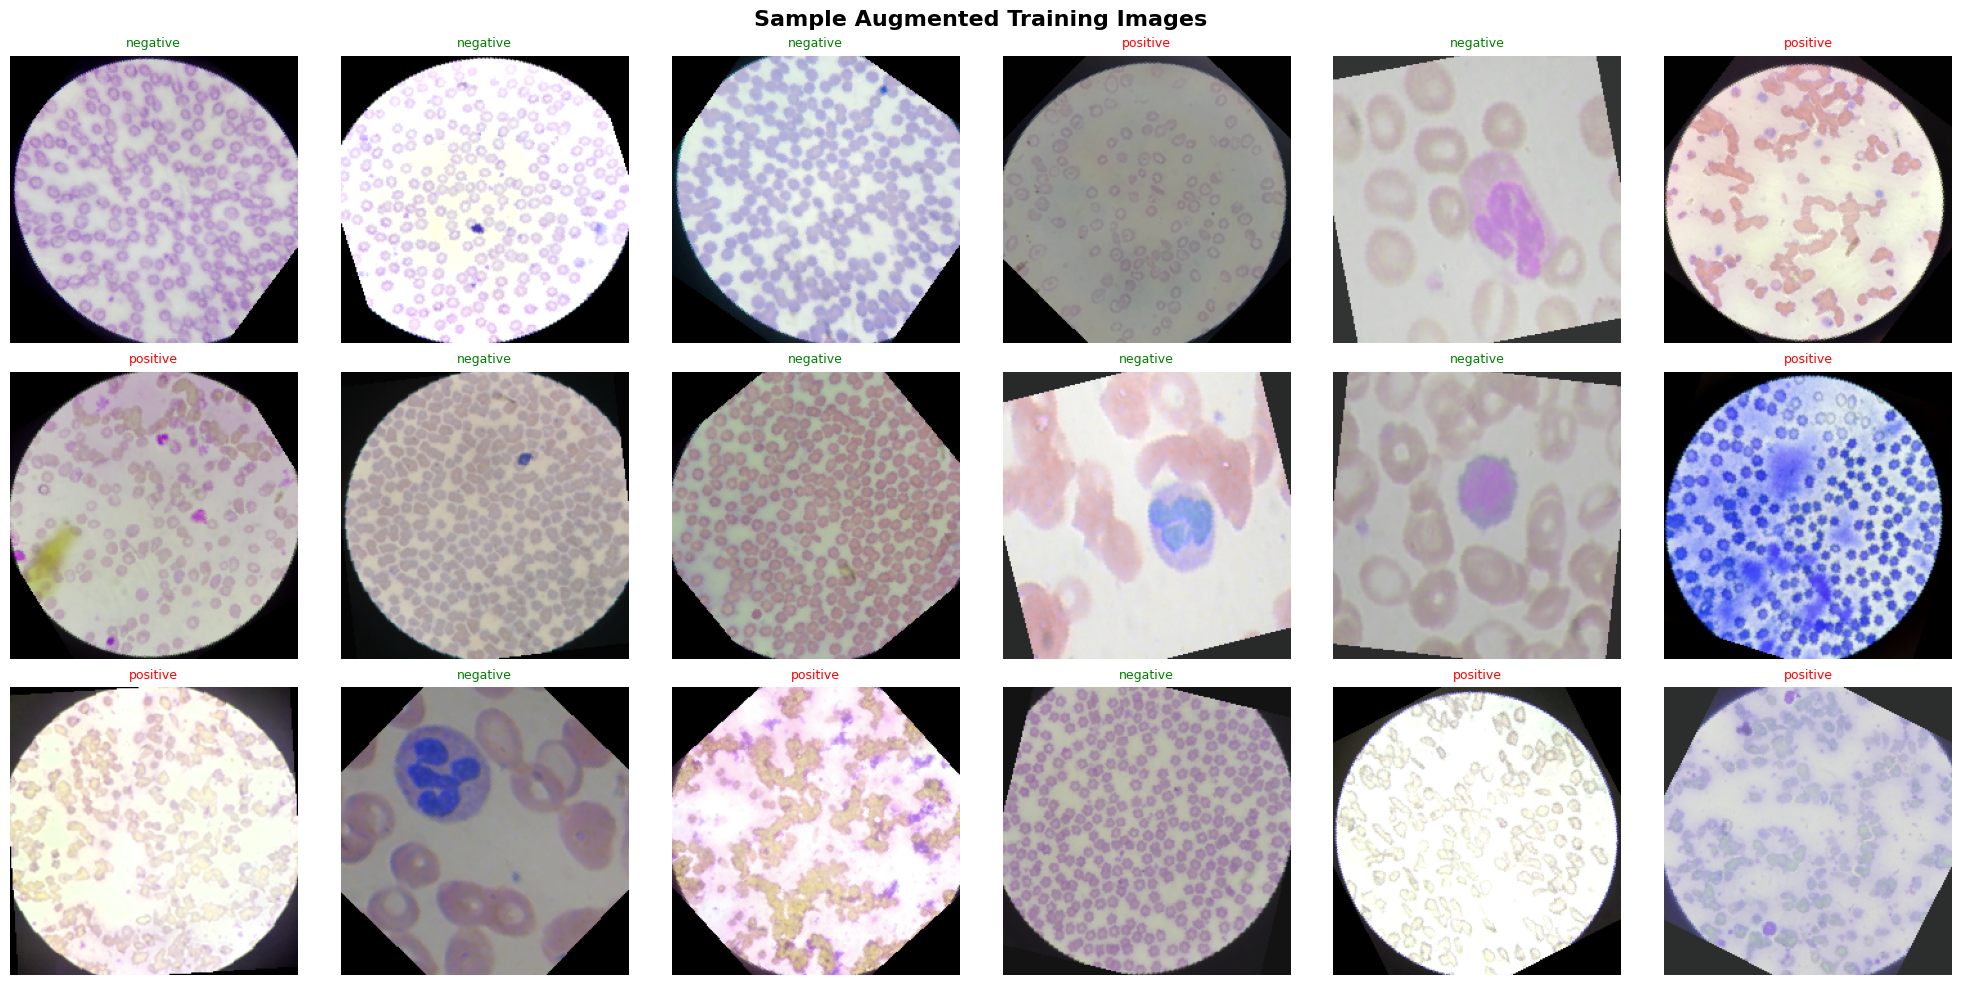

Augmented samples saved to figures folder


In [16]:
def denormalise(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Get a batch of training images
images, labels = next(iter(train_loader))
class_names = {v: k for k, v in train_dataset.class_to_idx.items()}

fig, axes = plt.subplots(3, 6, figsize=(20, 10))
fig.suptitle('Sample Augmented Training Images', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img = denormalise(images[i])
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i].item()], fontsize=9,
                 color='red' if labels[i].item() == 1 else 'green')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/augmented_samples.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Augmented samples saved to figures folder")

### Observations

The augmented training images confirm that the preprocessing pipeline
is working correctly. The natural circular black border from mobile
phone microscope capture is visible in Tushabe images while BCCD images
appear as standard rectangular photographs, reflecting the known domain
difference between the two data sources.

Importantly, no bounding box annotation artefacts are visible in any
image, confirming that the exclusion of the 422 labelled Tushabe images
was successful. The augmentation pipeline is producing realistic
variations in orientation, brightness, contrast, and scale without
distorting cell morphology beyond recognition.

The preprocessing notebook is now complete. The cleaned and split
dataset is ready for model training in the subsequent notebooks.